# UdaciMed | Notebook 1: Baseline Analysis

Welcome to UdaciMed! You are a Machine Learning Engineer tasked with optimizing our chest X-ray pneumonia detection model for production deployment.

- **The challenge**: Before our new model can be approved for production, we must verify that it meets our strict performance SLAs. Deploying an unoptimized model could lead to high operational costs and poor performance across our diverse hardware fleet—from shared T4 GPU cloud instances to portable clinic devices.

- **Your mission**: Optimize the model to pass _UdaciMed's Universal Performance Standard_, a strict production service level agreement (SLA) that must be met using the universally compatible ONNX format on our standardized target device.

### **Optimization goals**

Your goal is to ensure the production model meets these production targets on our standardized development machine:

- **< 0.4 GFLOPs per sample**: Floating Point Operations determine computational cost - reducing FLOPs is the most critical step toward broad-platform efficiency.
- **< 100MB peak memory footprint**: Total memory consumption (parameters + activations + workspace) during inference - essential for running the model on memory-constrained edge devices and for enabling cost-effective multi-model environments in the cloud.
- **< 3ms latency**: This ensures a real-time user experience. We will measure both *amortized latency* (average time per sample in a large batch) and *true latency* (time for a single-image inference), as both are important for different use cases.
- **> 2000 samples/second throughput**: This specific target is for our high-performance hardware, like the reference T4 GPU. Meeting this goal proves the model is cost-effective and scalable for high-volume, server-side screening workflows.
- **> 98% sensitivity***: This is a non-negotiable clinical safety requirement. We must ensure that a threshold percentage of all true pneumonia cases are correctly identified. All optimizations must be validated against this metric.

#### **A note on our standardized target device**

All performance targets in this project must be met on our official _"standardized target device."_ This is an NVIDIA T4 GPU, a common and versatile datacenter GPU that represents a typical cloud deployment environment.

By using a single, consistent hardware profile (NVIDIA T4 with 16GB VRAM, CUDA 12.4) for all our performance SLAs, we can:

- *Ensure Reproducible Results*: Anyone on the team can validate performance and get consistent measurements.

- *Create a Reliable Benchmark*: It provides a stable baseline to measure the impact of every optimization we make.

If a model can meet our strict, universal performance standards on this reference hardware, we are confident it will perform well across our entire fleet of production devices.

---

Through this notebook, you will build the foundation for our optimization strategy by:

1.  **Establishing baseline performance** with comprehensive profiling.
2.  **Analyzing the primary bottlenecks**, distinguishing between compute, parameter memory, and activation memory.
3.  **Identifying optimization opportunities** in both the model architecture and the deployment configuration.

**Let's set up an optimization vision for UdaciMed's next-generation diagnostic platform!**


> **_\*Understanding medical AI requirements_**:
> 
> In medical AI, sensitivity (recall) is often more critical than overall accuracy. Missing a pneumonia case (false negative) can be life-threatening, while a false positive "only" leads to additional human review. This is why we prioritize sensitivity as our safety constraint.

## Step 1: Set up the environment
The first step is to import all libraries and internal functionalities (from `utils`). 

Additionally, we set `pytorch` to use CUDA GPU if available (not only for faster execution, but also for benchmarking, as this will be our final deployment target!) and we include deterministic mode for reproducible benchmarking.

In [1]:
# Make sure that libraries are dynamically re-loaded if changed
%load_ext autoreload
%autoreload 2

In [2]:
# Import core libraries
import torch
import torch.nn as nn
import inspect
import numpy as np
import os
import pickle
from pprint import pprint
import random
from torchsummary import summary
import tqdm
import warnings
warnings.filterwarnings('ignore')

# Import project utilities
from utils.data_loader import (
    load_pneumoniamnist, 
    get_dataset_info, 
    explore_dataset_splits,
    visualize_sample_images,
    get_sample_batch
)
from utils.model import (
    create_baseline_model,
    get_model_info,
    count_parameters_by_type,
    train_baseline_model,
    plot_training_history
)
from utils.evaluation import (
    evaluate_with_multiple_thresholds
)
from utils.profiling import (
    PerformanceProfiler,
    get_gpu_info,
    check_environment,
    measure_time
)
from utils.visualization import (
    plot_dataset_distribution,
    plot_performance_profile,
    plot_operation_breakdown,
    plot_batch_size_comparison,
)

# Check environment and GPU capabilities
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

if torch.cuda.is_available():
    gpu_info = get_gpu_info()
    print(f"GPU: {gpu_info.get('name', 'Unknown')}")
    print(f"GPU Memory: {gpu_info.get('memory_total_gb', 0):.1f} GB")
    print(f"Tensor Core Support: {gpu_info.get('tensor_core_support', False)}")
else:
    print("WARNING: CUDA not available - profiling will be limited")

Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
GPU Memory: 8.0 GB
Tensor Core Support: True


In [3]:
# Set random seed for reproducibility across optimization experiments
def set_deterministic_mode(seed=42):
    """
    Enable deterministic mode for consistent benchmarking.
    Critical for fair comparison between different techniques.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False  # Disable for consistent timing
    os.environ["PYTHONHASHSEED"] = str(seed)

set_deterministic_mode(42)
print("Deterministic mode enabled for reproducible benchmarking")

Deterministic mode enabled for reproducible benchmarking


## Step 2: Load and analyze the dataset
Now, we can get started with our baseline model set-up by loading the data and understanding its characteristics. 

For this project, we use the PneumoniaMNIST dataset from [MedMNIST](https://medmnist.com/). PneumoniaMNIST provides a standardized, validated dataset for pneumonia detection research. Its 64x64 resolution balances clinical detail with computational efficiency, making it ideal for optimization studies while maintaining diagnostic relevance.

In [4]:
# Get dataset information
dataset_info = get_dataset_info(use_binary=True)
print("PneumoniaMNIST Dataset Information:")
for key, value in dataset_info.items():
    print(f"   {key.replace('_', ' ').title()}: {value}")

PneumoniaMNIST Dataset Information:
   Name: PneumoniaMNIST
   Task: Binary classification (Normal vs Pneumonia)
   Classes: ['Normal', 'Pneumonia']
   Num Classes: 2
   Source: Chest X-ray Images (Pneumonia) from Kaggle
   Original Size: Various sizes (medical imaging protocols vary)
   Processed Sizes: [28, 64, 128, 224]
   Medical Context: Pneumonia detection in chest X-rays for clinical decision support
   Samples: {'train': 4708, 'val': 524, 'test': 624}
   Total Samples: 5856
   Clinical Significance: Early pneumonia detection critical for patient outcomes
   Preprocessing Note: ImageNet normalization applied for transfer learning optimization


In [5]:
# Define configuration for baseline analysis
CONFIG = {
    'image_size': 64,  # Balanced for for memory usage and model accuracy
    'num_classes': 2,  # Binary classification: normal vs pneumonia
    'batch_size': 32,  # Balanced for memory usage and training stability
    'subset_size': None,  # Use full dataset for production-representative results
    'use_xray_stats': True,  # Use X-ray specific normalization statistics
    'stats_max_samples': None,  # Limit samples for stats computation to speed
}

# Load the dataset with optimized settings
print("Loading PneumoniaMNIST dataset...")

with measure_time("Dataset loading"):
    train_loader = load_pneumoniamnist(
        split="train", download=True, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.7 if CONFIG['subset_size'] is not None else None,
        use_xray_stats=CONFIG['use_xray_stats'],
        stats_max_samples=CONFIG['stats_max_samples']
    )
    
    val_loader = load_pneumoniamnist(
        split="val", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None,
        use_xray_stats=CONFIG['use_xray_stats'],
        stats_max_samples=CONFIG['stats_max_samples']
    )
    
    test_loader = load_pneumoniamnist(
        split="test", download=False, 
        size=CONFIG['image_size'], batch_size=CONFIG['batch_size'], 
        subset_size=CONFIG['subset_size'] * 0.15 if CONFIG['subset_size'] is not None else None,
        use_xray_stats=CONFIG['use_xray_stats'],
        stats_max_samples=CONFIG['stats_max_samples']
    )

print(f"Dataset loaded: {CONFIG['image_size']}x{CONFIG['image_size']} images, batch_size={CONFIG['batch_size']}")

Loading PneumoniaMNIST dataset...
⏱️ Dataset loading took 225.83 ms
Dataset loaded: 64x64 images, batch_size=32


Analyzing dataset distribution...

Dataset Summary: {'train': {'total': 4708, 'class_stats': {'normal': 1214, 'pneumonia': 3494, 'type': 'binary'}, 'normal': 1214, 'pneumonia': 3494, 'pneumonia_ratio': 0.7421410365335599}, 'val': {'total': 524, 'class_stats': {'normal': 135, 'pneumonia': 389, 'type': 'binary'}, 'normal': 135, 'pneumonia': 389, 'pneumonia_ratio': 0.7423664122137404}, 'test': {'total': 624, 'class_stats': {'normal': 234, 'pneumonia': 390, 'type': 'binary'}, 'normal': 234, 'pneumonia': 390, 'pneumonia_ratio': 0.625}}


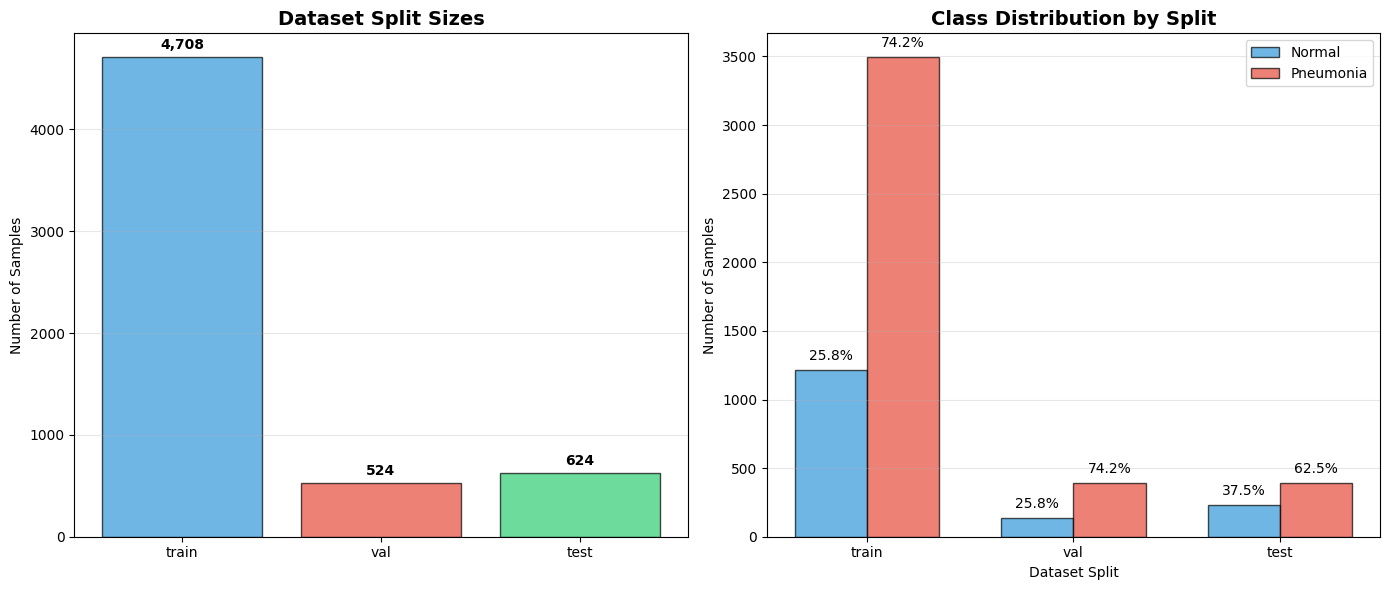

In [6]:
# Analyze dataset distribution for class imbalance considerations
print("Analyzing dataset distribution...")
dataset_splits = explore_dataset_splits(train_loader, val_loader, test_loader)
print(f"\nDataset Summary: {dataset_splits}")

# Visualize dataset distribution
plot_dataset_distribution(dataset_splits)

> **_The impact of class imbalance_**
> 
> Medical datasets often have class imbalance. This affects optimization because:
> 
> - Models may focus compute on majority class features
> - Batch composition affects memory usage patterns
> - Some optimization techniques (like pruning) may disproportionately affect minority class performance

Sample chest X-ray images:


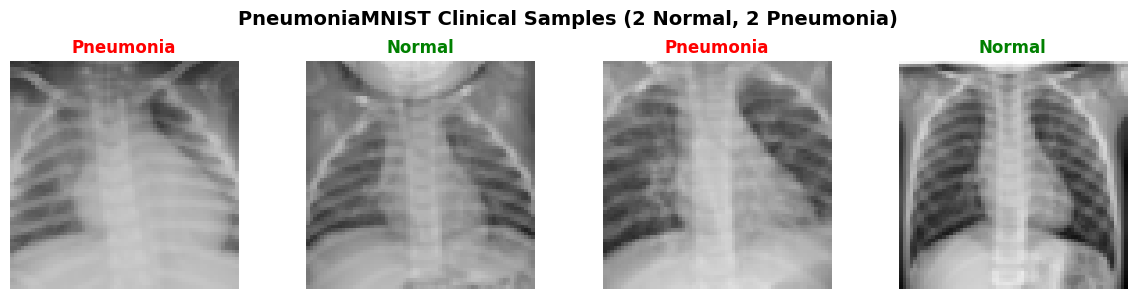

Displayed 4 images: 2 normal, 2 pneumonia


In [7]:
# Visualize sample images to understand data characteristics
print("Sample chest X-ray images:")
visualize_sample_images(train_loader, num_samples=4)

## Step 3: Create and analyze the baseline model
We will use [ResNet-18](https://docs.pytorch.org/vision/main/models/generated/torchvision.models.resnet18.html) as our baseline - a popular choice for medical imaging that balances accuracy and efficiency.

The original model structure is architected for ImageNet (1000 classes), so we modify the model with a custom head to support our new classification task.

In [8]:
# Create the baseline ResNet-18 model
print("Creating ResNet-18 baseline model...")

baseline_model = create_baseline_model(
    num_classes=CONFIG['num_classes'], 
    input_size=CONFIG['image_size'], # 64x64 input images
    pretrained=False  # Training from scratch for fair optimization comparison
)
baseline_model = baseline_model.to(device)

print(f"Baseline model created and deployed to {device}")
print(f"   Architecture: {baseline_model.architecture_name}")

Creating ResNet-18 baseline model...
Baseline model created and deployed to cuda
   Architecture: ResNet-18-Adaptive


In [9]:
# Get model information
model_info = get_model_info(baseline_model)

print(f"\nModel Information:")
print(f"   Architecture: {model_info['architecture']}")
print(f"   Total Parameters: {model_info['total_parameters']:,}")
print(f"   Model Size: {model_info['model_size_mb']:.1f} MB")
print(f"   Input Size: {model_info['input_size']}x{model_info['input_size']}")

# Analyze layer composition 
layer_breakdown = model_info['layer_breakdown']
print(f"\nLayer Composition:")
print(f"   Convolution Layers: {layer_breakdown['conv_layers']['count']} ({layer_breakdown['conv_layers']['total_params']:,} params)")
print(f"   Linear Layers: {layer_breakdown['linear_layers']['count']} ({layer_breakdown['linear_layers']['total_params']:,} params)")
print(f"   Normalization Layers: {layer_breakdown['norm_layers']['count']}")
print(f"   Activation Types: {', '.join(layer_breakdown['activation_layers']['types'])}")

# Get parameter distribution
if 'parameter_distribution' in layer_breakdown:
    param_dist = layer_breakdown['parameter_distribution']
    print(f"\nParameter Distribution:")
    print(f"   Convolution: {param_dist['conv_percentage']:.2f}%")
    print(f"   Linear: {param_dist['linear_percentage']:.2f}%")


Model Information:
   Architecture: ResNet-18-Adaptive
   Total Parameters: 11,177,538
   Model Size: 42.6 MB
   Input Size: 64x64

Layer Composition:
   Convolution Layers: 20 (11,166,912 params)
   Linear Layers: 1 (1,026 params)
   Normalization Layers: 20
   Activation Types: ReLU

Parameter Distribution:
   Convolution: 99.99%
   Linear: 0.01%


In [10]:
# Display the model architecture
summary(baseline_model, input_size=(3, CONFIG["image_size"], CONFIG["image_size"]))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

> **_Brainstorming time: Optimizations by layer type_**
> 
> Try to remember from the course, which architectural optimizations most benefit each layer type? Looking at the layer composition, our model is convolution-heavy - this is your starting point!

## Step 4: Train and evaluate baseline model
Now, we define the baseline model and evaluate its performance on key accuracy metrics - all future optimizations should maintain a similar clinical performance standard.

Establishing robust baseline metrics is crucial for medical AI. Any optimization must preserve clinical safety while improving computational efficiency.

Starting baseline model training for pneumonia detection...
   Config: 10 epochs, lr=0.0003, wd=0.0001


   Epoch  1: Train Acc  92.5% | Val Acc  71.9% | Train Loss 0.2020 | Val Loss 1.2140 | LR 0.000300
      New best model saved (Val Acc: 71.9%)


   Epoch  2: Train Acc  95.5% | Val Acc  95.6% | Train Loss 0.1182 | Val Loss 0.1513 | LR 0.000300
      New best model saved (Val Acc: 95.6%)


   Epoch  3: Train Acc  96.2% | Val Acc  95.4% | Train Loss 0.1134 | Val Loss 0.1069 | LR 0.000300


   Epoch  4: Train Acc  97.9% | Val Acc  97.3% | Train Loss 0.0604 | Val Loss 0.0667 | LR 0.000030
      New best model saved (Val Acc: 97.3%)


   Epoch  5: Train Acc  98.5% | Val Acc  97.5% | Train Loss 0.0406 | Val Loss 0.0614 | LR 0.000030
      New best model saved (Val Acc: 97.5%)


   Epoch  6: Train Acc  98.9% | Val Acc  97.9% | Train Loss 0.0334 | Val Loss 0.0655 | LR 0.000030
      New best model saved (Val Acc: 97.9%)


   Epoch  7: Train Acc  99.2% | Val Acc  97.5% | Train Loss 0.0274 | Val Loss 0.0655 | LR 0.000003


   Epoch  8: Train Acc  99.3% | Val Acc  97.3% | Train Loss 0.0210 | Val Loss 0.0645 | LR 0.000003


   Epoch  9: Train Acc  99.2% | Val Acc  97.3% | Train Loss 0.0199 | Val Loss 0.0626 | LR 0.000003
     Early stopping triggered after 9 epochs (patience: 3)
Training completed! Best validation accuracy: 97.90%


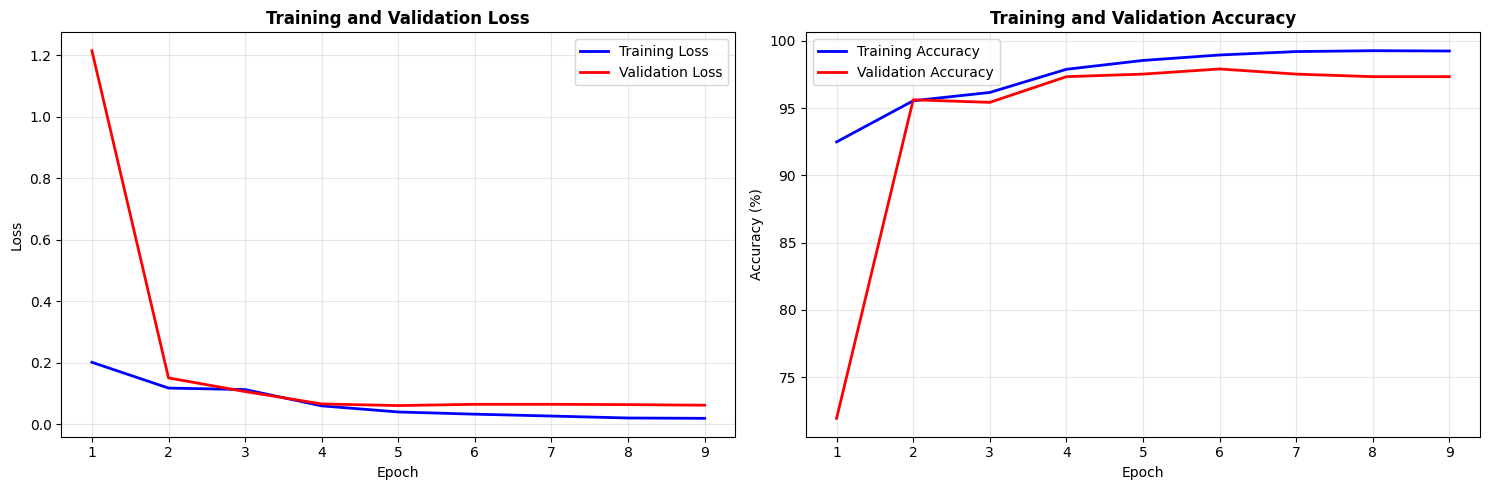


Training Summary:
   Best Validation Accuracy: 97.9%
   Total Epochs: 9
   Final Training Accuracy: 99.2%
   Final Validation Accuracy: 97.3%


In [11]:
# Training configuration
TRAINING_CONFIG = {
    'num_epochs': 10,           # Sufficient for convergence analysis
    'learning_rate': 0.0003,    # Conservative rate for stable training
    'lr_step_size': 3,          # Learning rate decay schedule
    'weight_decay': 1e-4,       # Regularization for generalization
    'patience': 3               # Early stopping for efficiency
}

# Train the model
baseline_model, training_history = train_baseline_model(
    baseline_model, train_loader, val_loader, device, TRAINING_CONFIG
)

# Plot training curves with analysis
plot_training_history(training_history)

> **Training insights: What does the training history tell us?**
> 
> The initial low validation accuracy is due to extreme overfitting due to the small dataset size in comparison to the model's parameter size. The presence of early plateaus and fast convergence also highlight that the architecture has high representational power - we can likely apply aggressive optimization without accuracy degradation.

In [12]:
# Evaluate model performance with multiple thresholds 
print(f"Running eval benchmark on {dataset_splits['test']['total']} test samples ...")
eval_results = evaluate_with_multiple_thresholds(baseline_model, test_loader, device, [0.4, 0.7])

Running eval benchmark on 624 test samples ...

Evaluating with threshold 0.4:
Clinical Evaluation Results (threshold: 0.400):
   Accuracy:  82.7%
   Precision: 78.3% (PPV - Positive Predictive Value)
   Recall:    100.0% (Sensitivity)
   F1 Score:  87.8%
   AUC-ROC:   0.961

Confusion Matrix Analysis:
   True Negatives (Normal correctly identified):     126
   False Positives (Normal misclassified):           108
   False Negatives (Pneumonia missed):                 0
   True Positives (Pneumonia correctly detected):   390

Clinical Performance Interpretation:
   Sensitivity (True Positive Rate):     100.0% (detects 100.0% of pneumonia cases)
   Specificity (True Negative Rate):     53.8% (correctly identifies 53.8% of normal cases)
   PPV (Positive Predictive Value):      78.3% (when model predicts pneumonia, it's correct 78.3% of time)
   NPV (Negative Predictive Value):      100.0% (when model predicts normal, it's correct 100.0% of time)

Clinical Significance:
   False Negative 

> **Clinical threshold selection**
>
> Different thresholds optimize for different clinical scenarios. Lower thresholds (0.4) maximize sensitivity for screening, while higher thresholds (0.7) balance precision and recall for diagnostic confirmation.

## Step 5: Profile baseline model for latency, throughput, and memory usage

Comprehensive performance profiling forms the foundation of our optimization strategy. We will measure all key metrics that impact multi-tenant deployment.

In [13]:
# Initialize performance profiler
profiler = PerformanceProfiler(device=str(device))
print(f"Performance profiler initialized for {device}")

# Get sample batch for profiling
sample_images, sample_labels = get_sample_batch(val_loader)
sample_images = sample_images.to(device)
sample_labels = sample_labels.to(device)

print(f"\nSample batch for profiling:")
print(f"   Batch shape: {sample_images.shape}")
print(f"   Memory usage: {sample_images.numel() * sample_images.element_size() / 1024**2:.1f} MB")

Performance profiler initialized for cuda

Sample batch for profiling:
   Batch shape: torch.Size([32, 3, 64, 64])
   Memory usage: 1.5 MB


In [15]:
# Profile inference timing
print("Profiling inference timing...")

timing_results = profiler.profile_inference_time(
    model=baseline_model,
    input_tensor=sample_images,
    num_runs=100,       # Sufficient for statistical significance
    warmup_runs=10      # GPU warmup for consistent measurements
)

print(f"\nTiming Results:")
print(f"   Single Sample Latency: {timing_results['single_sample_ms']:.2f} ms")
print(f"   (Single) Batch Throughput: {timing_results['throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Batch Latency: {timing_results['batch_total_ms']:.2f} ms")
print(f"   Batch Throughput: {timing_results['batch_throughput_samples_per_sec']:.1f} samples/sec")
print(f"   Mean Inference Time: {timing_results['mean_ms']:.2f} ms")
print(f"   95th Percentile: {timing_results['p95_ms']:.2f} ms")
print(f"   Standard Deviation: {timing_results['std_ms']:.2f} ms")

Profiling inference timing...

Timing Results:
   Single Sample Latency: 3.59 ms
   (Single) Batch Throughput: 278.7 samples/sec
   Batch Latency: 16.48 ms
   Batch Throughput: 1942.2 samples/sec
   Mean Inference Time: 3.59 ms
   95th Percentile: 12.70 ms
   Standard Deviation: 2.61 ms


> **Latency vs throughput trade-offs**
>
> Single sample latency measures real-time diagnostic speed, while batch throughput indicates multi-tenant efficiency. Both metrics are crucial for different deployment scenarios.

In [16]:
# Profile FLOPs for computational efficiency analysis
flops_results = profiler.profile_flops(
    model=baseline_model, 
    input_tensor=sample_images
)

if 'error' in flops_results:
    print(f"FLOPs calculation failed: {flops_results['error']}")
else:
    print(f"\nFLOPs Results:")
    print(f"   Total: {flops_results['total_gflops']:.2f} GFLOPs")
    print(f"   Per Sample: {flops_results['gflops_per_sample']:.2f} GFLOPs")
    if 'module_percentage' in flops_results and flops_results['module_percentage']:
        print(f"\n   Top Operations (by FLOPs):")
        for module, percentage in list(flops_results['module_percentage'].items())[:5]:
            gflops = flops_results['module_breakdown_gflops'][module]
            print(f"     {module}: {percentage:.1f}% ({gflops:.2f} GFLOPs)")

Unsupported operator aten::max_pool2d encountered 1 time(s)
Unsupported operator aten::add_ encountered 8 time(s)



FLOPs Results:
   Total: 58.21 GFLOPs
   Per Sample: 1.82 GFLOPs

   Top Operations (by FLOPs):
     conv: 99.7% (58.03 GFLOPs)
     batch_norm: 0.3% (0.16 GFLOPs)
     upsample_bilinear2d: 0.0% (0.02 GFLOPs)
     adaptive_avg_pool2d: 0.0% (0.00 GFLOPs)
     linear: 0.0% (0.00 GFLOPs)


In [17]:
# Profile GPU memory usage
print("Profiling GPU memory usage...")

memory_results = profiler.profile_memory_usage(
    model=baseline_model,
    input_tensor=sample_images
)

if 'error' not in memory_results:
    print(f"\nMemory Results:")
    print(f"   Peak GPU Memory: {memory_results['peak_memory_mb']:.1f} MB")
    print(f"   Memory Increase: {memory_results['memory_increase_mb']:.1f} MB")
    
    # Component breakdown
    if 'component_breakdown' in memory_results:
        components = memory_results['component_breakdown']
        print(f"\nMemory Component Breakdown:")
        for component, usage in components.items():
            print(f"   {component.replace('_', ' ').title()}: {usage:.1f} MB")
else:
    print(f"WARNING: Memory profiling error: {memory_results['error']}")
    memory_results = {}

Profiling GPU memory usage...

Memory Results:
   Peak GPU Memory: 320.5 MB
   Memory Increase: 214.4 MB

Memory Component Breakdown:
   Model Parameters Mb: 42.6 MB
   Input Tensor Mb: 1.5 MB
   Output Tensor Mb: 0.0 MB
   Activations Mb: 212.9 MB


> **_Did you notice? A major optimization opportunity hiding in plain sight!_**
> 
> Look carefully at the model summary above. Something doesn't add up with our input/output dimensions...
> 
> Compare the input size we are feeding (64x64) with the first convolution layer's output size. The first Conv2d layer shows output `[-1, 64, 112, 112]` but our input is only 64x64. Where are those extra pixels coming from? Complete the TODO below to find out.
> 
> *Optimization opportunity:* This might be your biggest single optimization win, in both speed and memory usage! Keep this insight in mind as you analyze the profiling results below.

In [ ]:
# Inspect the baseline model's forward method using `inspect.get_source()`
import inspect

print("Manually inspect the ResNetBaseline forward method:")
baseline_model_forward = inspect.getsource(baseline_model.forward)
print(baseline_model_forward)

print("\nDiscussion questions:")
print("1. What happens when height != self.target_size? What is self.target_size set to?") 
print("2. How much computational and memory overhead does F.interpolate add? (Hint: Compare 64x64 vs 224x224 pixel counts)")
print("3. Is this interpolation necessary for pneumonia detection, or just a legacy from ImageNet pretraining?")

Manually inspect the ResNetBaseline forward method:
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with adaptive input interpolation for variable input sizes.
        
        Automatically handles input size adaptation to leverage ImageNet pretrained
        features optimally. Critical for medical imaging where input sizes may vary
        across different acquisition protocols.
        
        Args:
            x: Input tensor of shape (batch_size, channels, height, width)
            
        Returns:
            Output logits of shape (batch_size, num_classes) for classification
            
        Note:
            Bilinear interpolation maintains spatial relationships in medical images
            while adapting to the expected ImageNet input size for optimal
            pretrained feature utilization.
            
        Example:
            >>> model = ResNetBaseline()
            >>> input_tensor = torch.randn(8, 3, 28, 28)  # Vari

In [18]:
# Detailed PyTorch profiler
print("Running detailed PyTorch profiler...")

detailed_results = profiler.profile_with_pytorch_profiler(
    model=baseline_model,
    input_tensor=sample_images,
    num_steps=10        # Sufficient for operation breakdown analysis
)

if 'error' not in detailed_results:
    print(f"\nOperation Breakdown:")
    op_breakdown = detailed_results['operation_breakdown']
    
    # Show top operations for optimization targeting
    sorted_ops = sorted(op_breakdown.items(), key=lambda x: x[1], reverse=True)
    for op_type, percentage in sorted_ops:
        if percentage > 1:  # Only show operations > 1%
            print(f"   {op_type.replace('_', ' ').title()}: {percentage:.1f}%")
else:
    print(f"WARNING: Detailed profiling error: {detailed_results['error']}")
    detailed_results = {}

Running detailed PyTorch profiler...

Operation Breakdown:
   Convolution Ops: 48.6%
   Normalization Ops: 24.2%
   Other Ops: 17.3%
   Activation Ops: 4.5%
   Matrix Multiply Ops: 3.6%
   Pooling Ops: 1.5%


## Step 6: Visualize and save baseline model's performance

Comprehensive visualization helps understand optimization opportunities and track progress across optimization experiments.

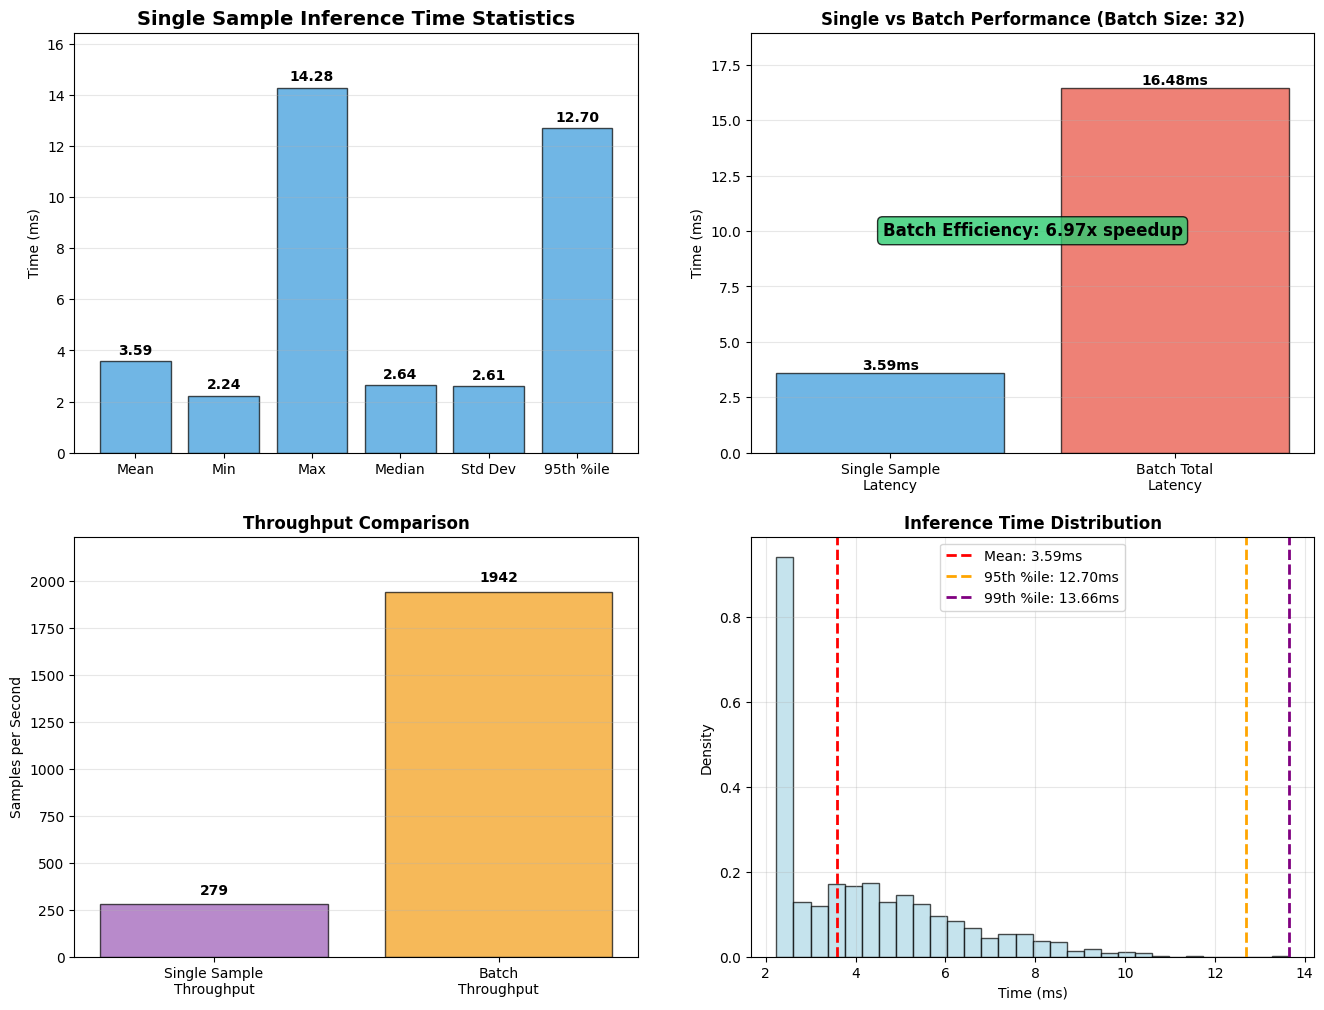

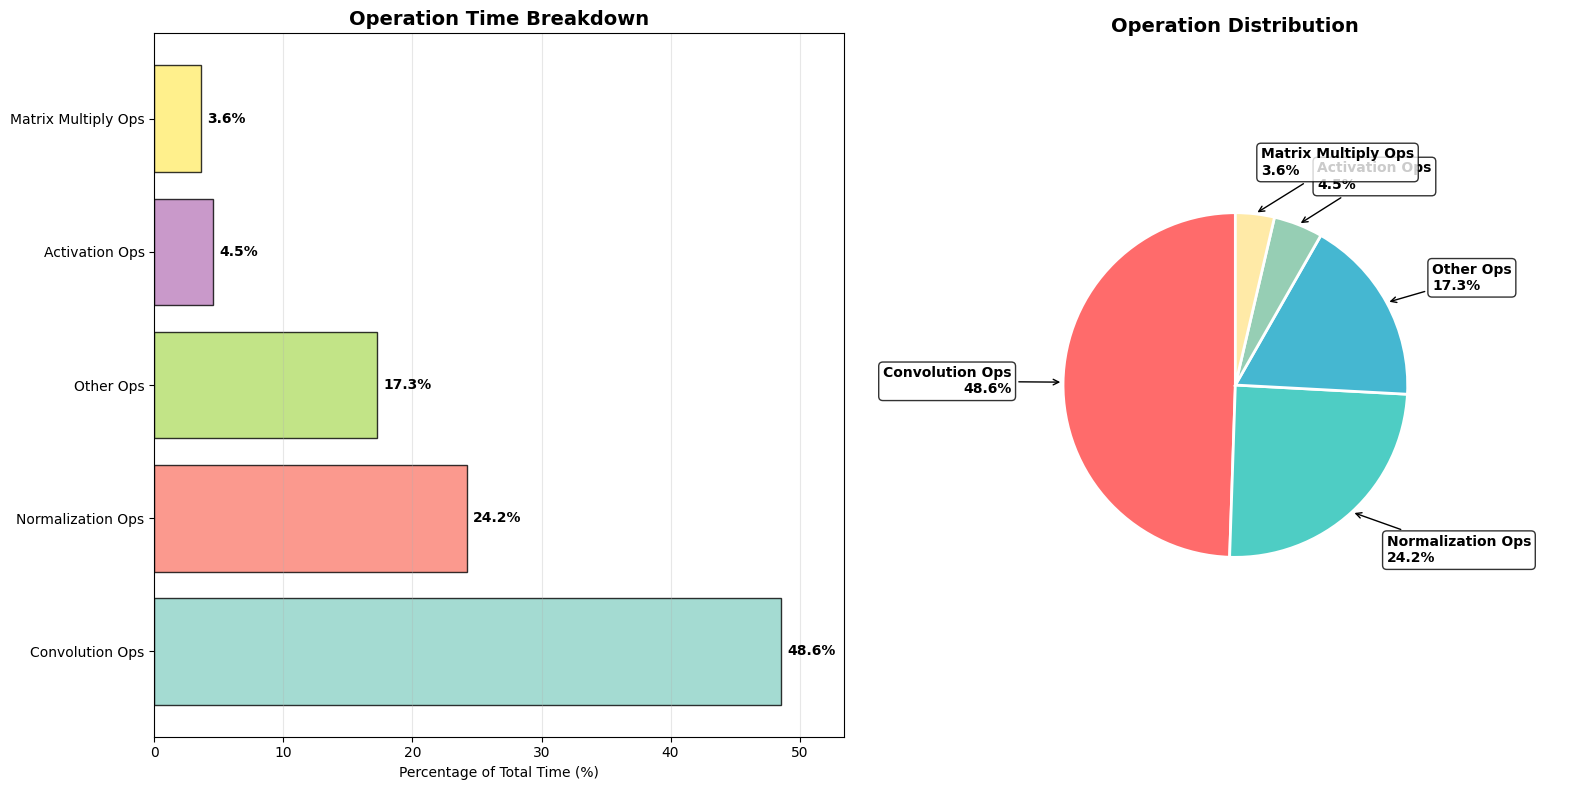

In [19]:
# Visualize performance profile
plot_performance_profile(timing_results)

# Visualize operation breakdown
if detailed_results and 'operation_breakdown' in detailed_results:
    plot_operation_breakdown(detailed_results['operation_breakdown'])
else:
    print("WARNING: Operation breakdown visualization not available")

In [20]:
# Compile baseline results for optimization notebooks
baseline_results = {
    'model_name': 'ResNet-18 Baseline',
    'architecture': model_info['architecture'],
    'total_parameters': model_info['total_parameters'],
    'model_size_mb': model_info['model_size_mb'],
    'config': CONFIG,
    'eval_results': eval_results,
    'timing': timing_results,
    'flops': flops_results,
    'memory': memory_results,
    'operation_breakdown': detailed_results['operation_breakdown'],
    'model_info': model_info,
    'dataset_info': dataset_info,
    'parameter_breakdown': count_parameters_by_type(baseline_model)
}

# Save baseline results
with open('./results/baseline_results.pkl', 'wb') as f:
    pickle.dump(baseline_results, f)

print("Baseline results saved to 'baseline_results.pkl' in the `results/` folder")
print("   This will be used for comparison in optimization notebooks.")

Baseline results saved to 'baseline_results.pkl' in the `results/` folder
   This will be used for comparison in optimization notebooks.


> **Brainstorming time!**
> 
> Based on your profiling results above, analyze the following:
> 
> 1. **Primary bottleneck**: What is the main performance bottleneck - compute time, memory usage, or data transfer?
> 
> 2. **Operation analysis**: Which types of operations (convolution, linear, activation) consume the most time? What percentage?
> 
> 3. **Memory patterns**: How much memory does the model use during inference? What contributes most to memory usage?
> 
> 4. **Optimization priority**: Based on the profiling data, which optimization techniques would you prioritize:
>    - Architecture modifications (channel reduction, efficient blocks)
>    - Precision optimization (mixed precision, quantization)
>    - Hardware acceleration (TensorRT for GPU, ...)
>   
>    _IMPORTANT:_ Did you discover the major inefficiency we hinted at earlier? How much improvement could removing the 64→224 interpolation provide?
>

Yes, I discovered it! The interpolation to 224x224 is probably not needed because we train from scratch (no pretrained weights) and control the input size. We can try out 64 or 128 and deactivate the interpolation step. This reduces a) the interpolation (of course) and b) the activation caches for the convolutions (receptive field is smaller, maybe this is still sufficient for the pneumonia dataset).

---

## Step 7: Analyze optimization opportunities

Now that we have established the baseline performance, it's time for you to conduct a deeper analysis that will guide the optimization strategy. This section contains **two focused analysis checkpoints**:

1. **Architecture optimization analysis** - Identify specific opportunities in the ResNet-18 architecture
2. **Deployment optimization analysis** - Understand hardware acceleration and deployment strategies

Complete these analysis checkpoints to develop your optimization roadmap!

### Analysis checkpoint 1: Architecture optimization opportunities

**Task:** Analyze the ResNet-18 architecture to identify the **top 2 optimization opportunities** from the techniques covered in the course. Available techniques to consider include:
- Grouped convolutions
- Depth-wise separable convolutions
- Inverted residuals with linear bottlenecks
- Low-rank factorization
- Channel organization strategies _(NOTE: this is a hybrid optimization between architecture and hardware)_
- Parameter sharing / weight tying

Feel free to skip programmatic analysis of techniques which you deem to be non-applicable or less performant, but provide an explanation here or in the notebook's final markdown cell.

**IMPORTANT:** Don't forget to also analyze the potential of interpolation removal from the model's forward method!

#### Recommended strategic analysis approach

Calculate the expected impact of applying each technique on parameter reduction programmatically to simplify follow-up analysis. Consider how parameter reduction / architectural improvements for each technique correlate with memory size (activation vs parameters), FLOPs, latency, throughput, and sensitivity to estimate optimization opportunity. HINTS are in each function's signature.

To populate the analysis dictionary with estimated optimiation opportunity, you can either:
1. Programmatically calculate optimization opportunity from parameter reduction and rule-of-thumb
2. Directly add the expected value in the analysis entries, and add a one-line explanation of the value selected as an in-line comment.

In [ ]:
# Run the complete architecture optimization analysis with all 5 implemented analysis functions above
from utils.analyze_functions import analyze_channel_organization_potential, analyze_conv_lowrank_factorization_potential, analyze_depthwise_separable_potential, analyze_grouped_conv_potential, analyze_interpolation_removal_potential, analyze_inverted_residuals_potential, analyze_lowrank_factorization_potential, analyze_parameter_sharing_potential


def run_architecture_optimization_analysis(model):
    """
    Main function to run all architecture optimization analyses.
    """
    print("Running architecture optimization analysis...")
    
    # Call each analysis function
    depthwise_analysis = analyze_depthwise_separable_potential(model, timing_results=timing_results, sample_input_shape=(3, CONFIG['image_size'], CONFIG['image_size']))
    grouped_analysis = analyze_grouped_conv_potential(model, groups=4, timing_results=timing_results, sample_input_shape=(3, CONFIG['image_size'], CONFIG['image_size']))
    inverted_analysis = analyze_inverted_residuals_potential(model, timing_results=timing_results)
    lowrank_analysis = analyze_lowrank_factorization_potential(model, min_weight_elements=10_000) # only for linear layers with >10k weights
    conv_lowrank_analysis = analyze_conv_lowrank_factorization_potential(model, timing_results=timing_results, sample_input_shape=(3, CONFIG['image_size'], CONFIG['image_size']))
    channel_analysis = analyze_channel_organization_potential(model, timing_results=timing_results)
    sharing_analysis = analyze_parameter_sharing_potential(model, timing_results=timing_results)
    interpolation_analysis = analyze_interpolation_removal_potential(model, timing_results=timing_results, sample_input_shape=(3, CONFIG['image_size'], CONFIG['image_size']))
    
    # Combine all analyses into comprehensive result
    # Remove any techniques which haven't been analyzed
    optimization_techniques = {
        'grouped_convolutions': {
            'candidate_layers': grouped_analysis['total_candidates'],
            'groups': grouped_analysis['groups'],
            'avg_param_reduction_percent': grouped_analysis['avg_param_reduction_percent'],
            'estimated_speedup': grouped_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': grouped_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': grouped_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': grouped_analysis['throughput_improvement_percent'],
            'sensitivity_risk': grouped_analysis['sensitivity_risk'],
            'details': grouped_analysis['candidate_layers'][:3]  # Show top 3
        },
        'depthwise_separable': {
            'candidate_layers': depthwise_analysis['total_candidates'],
            'avg_param_reduction_percent': depthwise_analysis['avg_param_reduction_percent'],
            'estimated_speedup': depthwise_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': depthwise_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': depthwise_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': depthwise_analysis['throughput_improvement_percent'],
            'sensitivity_risk': depthwise_analysis['sensitivity_risk'],
            'details': depthwise_analysis['candidate_layers'][:3]  # Show top 3
        },
        'inverted_residuals': {
            'expansion_candidates': inverted_analysis['total_candidates'],
            'estimated_speedup': inverted_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': inverted_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': inverted_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': inverted_analysis['throughput_improvement_percent'],
            'sensitivity_risk': inverted_analysis['sensitivity_risk']
        },
        'low_rank_factorization': {
            'candidate_layers': lowrank_analysis['total_candidates'],
            'avg_param_reduction_percent': lowrank_analysis['avg_param_reduction_percent'],
            'estimated_speedup': lowrank_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': lowrank_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': lowrank_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': lowrank_analysis['throughput_improvement_percent'],
            'sensitivity_risk': lowrank_analysis['sensitivity_risk']
        },
        'conv_low_rank_factorization': {
            'candidate_layers': conv_lowrank_analysis['total_candidates'],
            'avg_param_reduction_percent': conv_lowrank_analysis['avg_param_reduction_percent'],
            'estimated_speedup': conv_lowrank_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': conv_lowrank_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': conv_lowrank_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': conv_lowrank_analysis['throughput_improvement_percent'],
            'sensitivity_risk': conv_lowrank_analysis['sensitivity_risk']
        },
        'channel_organization': {
            'inplace_opportunities': channel_analysis['inplace_opportunities'],
            'estimated_speedup': channel_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': channel_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': channel_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': channel_analysis['throughput_improvement_percent'],
            'sensitivity_risk': channel_analysis['sensitivity_risk']
        },
        'parameter_sharing': {
            'sharing_potential_percent': sharing_analysis['sharing_potential_percent'],
            'estimated_speedup': sharing_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': sharing_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': sharing_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': sharing_analysis['throughput_improvement_percent'],
            'sensitivity_risk': sharing_analysis['sensitivity_risk']
        },
        'interpolation_removal': {
            'current_input_size': interpolation_analysis["interpolation_size"],
            'native_input_size': interpolation_analysis["original_image_size"],
            'estimated_speedup': interpolation_analysis['estimated_speedup'],
            'avg_flop_reduction_percent': interpolation_analysis['avg_flop_reduction_percent'],
            'estimated_memory_reduction_mb': interpolation_analysis['estimated_memory_reduction_mb'],
            'throughput_improvement_percent': interpolation_analysis['throughput_improvement_percent'],
            'sensitivity_risk': interpolation_analysis['sensitivity_risk']
        }
    }
    
    return optimization_techniques

import textwrap

def _format_value(value, indent=6, width=80):
    """
    Format values for pretty console output:
    - Floats: round to max 2 decimals
    - Dict/List: print compactly
    - Strings: line-wrap
    """
    prefix = " " * indent

    if isinstance(value, float):
        return f"{value:.2f}"

    if isinstance(value, int):
        return str(value)

    if isinstance(value, str):
        return "\n".join(
            textwrap.wrap(
                value,
                width=width,
                initial_indent="",
                subsequent_indent=prefix
            )
        )

    if isinstance(value, (list, dict)):
        return str(value)

    return str(value)

# Execute architecture analysis
arch_analysis = run_architecture_optimization_analysis(baseline_model)

# Display results
print("\nARCHITECTURE OPTIMIZATION RESULTS:")

for technique, details in arch_analysis.items():
    title = technique.replace("_", " ").title()
    print(f"\n   {title}:")

    for key, value in details.items():
        key_title = key.replace("_", " ").title()
        formatted_value = _format_value(value)

        # Sensitivity Risk gets extra spacing for readability
        if key.lower() == "sensitivity_risk":
            print(f"     {key_title}:")
            print(f"       {formatted_value}")
        else:
            print(f"     {key_title}: {formatted_value}")

Running architecture optimization analysis...

ARCHITECTURE OPTIMIZATION RESULTS:

   Grouped Convolutions:
     Candidate Layers: 16
     Groups: 4
     Avg Param Reduction Percent: 75.00
     Estimated Speedup: 2.11
     Avg Flop Reduction Percent: 75.00
     Estimated Memory Reduction Mb: 31.43
     Throughput Improvement Percent: 110.53
     Sensitivity Risk:
       Moderate: grouped conv reduces cross-channel mixing. Low risk for small groups
      (2–4), higher risk if applied aggressively or early.
     Details: [{'name': 'model.layer1.0.conv1', 'in_channels': 64, 'out_channels': 64, 'kernel_size': (3, 3), 'output_hw': (56, 56), 'base_params': 36864, 'grouped_params': 9216, 'param_reduction_percent': 75.0, 'base_macs': 115605504, 'grouped_macs': 28901376, 'flop_reduction_percent': 75.0}, {'name': 'model.layer1.0.conv2', 'in_channels': 64, 'out_channels': 64, 'kernel_size': (3, 3), 'output_hw': (56, 56), 'base_params': 36864, 'grouped_params': 9216, 'param_reduction_percent': 75.

> **_Before you move on...brainstorming time!_**
> 
> Based on your architecture analysis results, collect yours insights on architectural opportunities
> 
> 1. **Primary bottleneck**: What operation type consumes the most compute time in your model? Why does this pattern make sense for ResNet-18 architecture? How does this inform your optimization strategy?
> 
> 2. **Resource trade-offs:**: Which optimizations reduce parameters vs which improve compute efficiency? How might accuracy be affected by each technique?
> 
> 3. **Optimization priority**: In which order would you recommend implementing the 5 architectural techniques? Consider both impact and implementation difficulty.
> 
> 4. **Feasibility assessment:**: Will the combined optimizations achieve the 3ms target? If not, what additional techniques might be needed?

### Summary of analysis checkpoint 1

#### 1) Primary bottleneck

**Convolutions dominate compute time**, specifically the **3×3 Conv2d layers inside the BasicBlocks**. That’s exactly what the architectural analysis is picking up: almost every “candidate layer” list is basically “all 3×3 convs in the residual blocks”.

Why this makes sense for ResNet-18:

* ResNet-18 has very little in the head (512 → 2 linear), so FC is negligible.
* Most parameters and MACs sit in the mid and late stages (128/256/512 channels), and 3×3 convs scale as
  $$
  H\cdot W \cdot C_{in}\cdot C_{out}\cdot k^2
  $$
  so they explode with spatial size and channel width.
* The (default) **interpolation to 224×224** makes it worse because all early blocks run at much larger $H\cdot W$$ than necessary for a dataset that is natively 64×64.

How this informs strategy:

* So good targets to attack are **(a)** spatial size first (interpolation removal), then **(b)** convolution structure (depthwise/grouped/low-rank), and only then **(c)** execution layout tweaks (channels_last).
* Anything that touches only the classifier head is irrelevant here (the low-rank linear result confirms that).

---

#### 2) Resource trade-offs

Here’s the clean split between **parameter reduction** and **compute efficiency**, plus the likely accuracy risk:

**Primarily compute efficiency**

* **Interpolation removal (1.88×, ~92% MAC reduction)**
  Big compute win because it reduces $H\cdot W$ everywhere. Risk is **moderate**: retrain/validate is a must because the network now sees a different “effective scale” and receptive-field progression.
* **Depthwise separable (theoretical 5.45×, ~88% MAC reduction)**
  Huge compute+param reduction on paper, but **high accuracy risk** because of removal of cross-channel spatial mixing. In ResNet-18 this is a structural change, so expect retraining and non-trivial drop unless redesign is taken out carefully.
* **Grouped conv (2.11×, ~75% MAC reduction)**
  Strong compute+param reduction with **moderate risk**. Less aggressive than depthwise, still reduces channel mixing. Usually needs tuning per stage.

**Primarily parameter memory**

* **Parameter sharing (25% cap, ~24 MB params saved)**
  Mostly reduces model size on disk and weight memory. **Compute unchanged** in principle, speedup claims are weak. **High conceptual risk** because you constrain learning across depth; retrain required.

**Mixed (compute+params, but more “surgical” than depthwise)**

* **Conv low-rank (1.53×, ~45% MAC reduction)**
  Moderate gains, moderate–high risk. It changes each conv into two convs, so kernel scheduling can hurt. Accuracy impact depends on chosen ranks and where applied.

**Execution efficiency**

* **Channel organization (1.07×)**
  Low risk, small but reliable gains on many GPUs. No accuracy change.

---

#### 3) Optimization priority (top 5, ordered)

If I optimize for “most likely to work” rather than “biggest theoretical number”, I’d do:

1. **Interpolation removal**
   Biggest real win and conceptually clean. Training is already from scratch, which lowers risk compared to ImageNet-pretrained constraints.

2. **Channel organization (channels_last)**
   Almost free, low risk, quick win. It should be done early because it improves all later benchmarking reliability.

3. **Grouped convolutions (selectively, later stages first)**
   Moderate risk, good gains. Start with deeper stages (256/512 channels) where risk is lower and compute is high.

4. **Conv low-rank factorization (selectively, later stages first)**
   Works as a “dial” (rank_ratio) to trade accuracy vs speed. Use it when grouped conv isn’t enough, still less radical than full depthwise.

5. **Depthwise separable (only if needed, and not everywhere)**
   Theoretical monster, but highest risk in ResNet-18. If I do it, I do it stage-wise (late stages first), and expect a redesign plus retraining.

I would **not** prioritize parameter sharing in a speed-targeted project. It’s more “compression for size” than “latency for inference”, and it pushes you into “new architecture” territory with high accuracy risk.

---

#### 4) Feasibility: will these hit 3 ms?

**Probably not on paper if the current baseline is around ~6–10 ms**, because those speedups are not multiplicative in the real world. Amdahl’s law bites hard and kernel/overhead dominates once we shrink compute.

What is plausible:

* **Interpolation removal (~1.88×)** is the biggest single real lever here.
* **channels_last (~1.07×)** stacks nicely but is small.
* After that, real speedups from grouped/low-rank/depthwise will depend heavily on:

  * whether the backend uses optimized kernels for these patterns
  * whether I keep batch sizes comparable
  * whether memory bandwidth and launch overhead become dominant

So: we might get close, but **3 ms is aggressive** unless the profiling shows a large scalable conv portion even after removing interpolation.

Additional techniques if 3 ms is still missed:

* **Quantization (FP16 / INT8)** for GPU inference, preferably with TensorRT if allowed.
* **Torch compile / TorchScript + fusion**, if your pipeline includes it and the target runtime benefits.
* **ONNX export + TensorRT** (if deployment allows), often the practical path for a hard latency target.
* **Smaller backbone swap** (MobileNetV3 / EfficientNet-lite) instead of trying to “turn ResNet into MobileNet”. This is often the most honest route if accuracy holds.


### Analysis checkpoint 2: Deployment optimization opportunities

**Task:** Analyze deployment characteristics for our reference hardware, with a focus on batch processing trade-offs and mixed precision acceleration.

_Feel free to also add considerations from other hardware optimization techniques, such as leveraging specialized hardware acceleration units (e.g., Tensor Cores, NPUs) and other memory optimization patterns._

Running Deployment Optimization Analysis...
   Profiling multiple batch sizes...


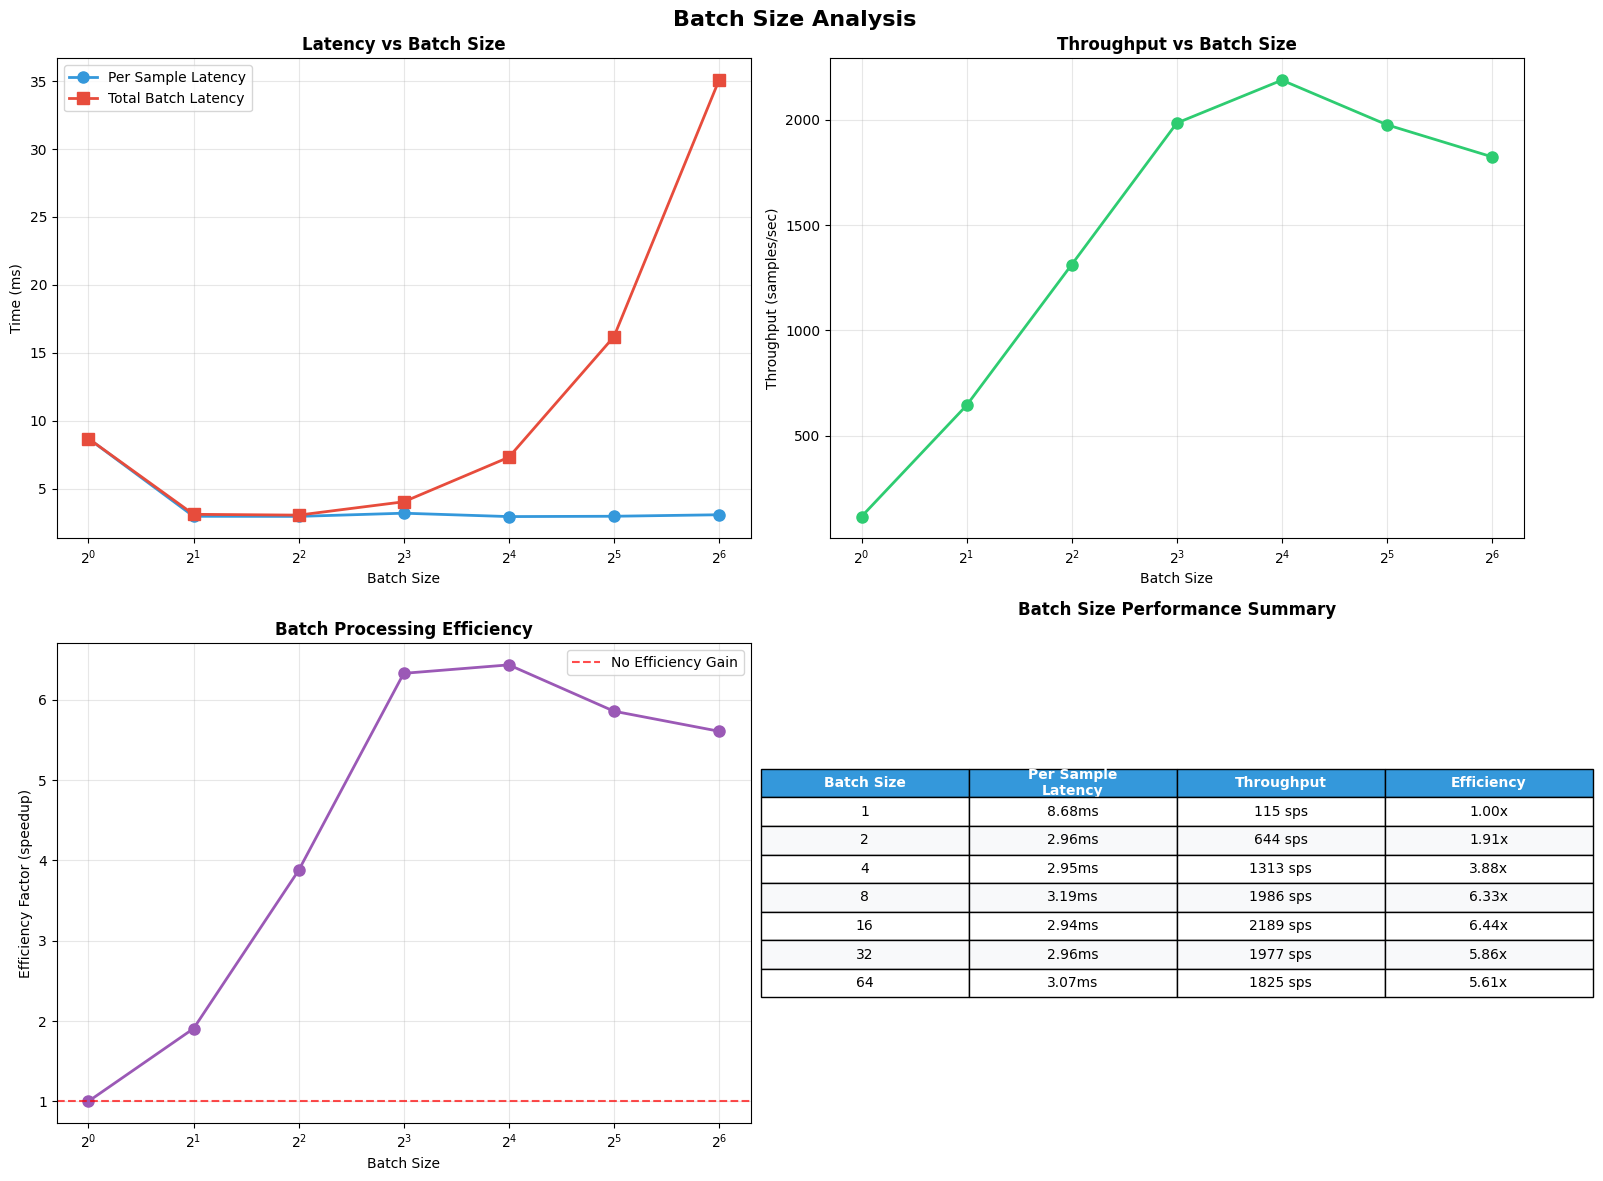


DEPLOYMENT OPTIMIZATION RESULTS:

   Mixed Precision (FP16):
     Tensor Core Eligible: 52.1%
     Estimated FLOP improvements: 0.0MB
     Estimated Speedup: 1.8x
     Estimated Throughput improvements %: 83.0%
     Estimated Memory Savings: 160.2MB
     Estimated Sensitivity Risk: Low to moderate: FP16 inference typically preserves accuracy with proper autocast and FP32 accumulation, but numerical edge cases can shift logits slightly. Validate sensitivity at the chosen operating threshold after enabling FP16.

   Deployment Scenarios:
     Real Time Diagnosis:
       Optimal Batch Size: 16
       Use Case: Emergency diagnosis, single patient processing
     Batch Processing:
       Optimal Batch Size: 16
       Use Case: Screening workflows, research processing


In [23]:
# Run the complete deployment optimization analysis with all 2 implemented analysis functions above
from utils.analyze_functions import analyze_batch_processing_scenarios, analyze_mixed_precision_potential


def run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results, profiler):
    """
    Main function to run all deployment optimization analyses.
    """
    print("Running Deployment Optimization Analysis...")

    # Analyze mixed precision potential
    mixed_precision = analyze_mixed_precision_potential(detailed_results, timing_results, memory_results)
    mixed_precision_speedup = mixed_precision['estimated_speedup']
    
    # Analyze batch processing scenarios
    batch_results, batch_scenarios = analyze_batch_processing_scenarios(baseline_model, mixed_precision_speedup, profiler, sample_images)
    # Visualize batch size analysis for deployment understanding
    plot_batch_size_comparison(batch_results)

    # Calculate deployment readiness
    current_latency = timing_results['single_sample_ms']
    current_throughput = timing_results['throughput_samples_per_sec']
    
    performance_metrics = {
        'latency_ms': current_latency,
        'throughput_samples_sec': current_throughput
    }
    
    return {
        'mixed_precision': mixed_precision,
        'batch_scenarios': batch_scenarios
    }

# Execute deployment analysis
deployment_analysis = run_deployment_optimization_analysis(baseline_model, timing_results, memory_results, detailed_results, profiler)

print(f"\nDEPLOYMENT OPTIMIZATION RESULTS:")
mp_details = deployment_analysis['mixed_precision']
print(f"\n   Mixed Precision (FP16):")
print(f"     Tensor Core Eligible: {mp_details['mixed_precision_coverage_percent']:.1f}%")
print(f"     Estimated FLOP improvements: {mp_details['avg_flop_reduction_percent']:.1f}MB")
print(f"     Estimated Speedup: {mp_details['estimated_speedup']:.1f}x")
print(f"     Estimated Throughput improvements %: {mp_details['throughput_improvement_percent']:.1f}%")
print(f"     Estimated Memory Savings: {mp_details['estimated_memory_reduction_mb']:.1f}MB")
print(f"     Estimated Sensitivity Risk: {mp_details['sensitivity_risk']}")

if 'error' not in deployment_analysis['batch_scenarios']:
    scenarios = deployment_analysis['batch_scenarios']
    print(f"\n   Deployment Scenarios:")
    for scenario, details in scenarios.items():
        print(f"     {scenario.replace('_', ' ').title()}:")
        print(f"       Optimal Batch Size: {details['optimal_batch_size']}")
        print(f"       Use Case: {details['use_case']}")

> **_Before you move on...brainstorming time!_**
> 
> Based on your deployment analysis results above, collect your thoughts about hardware deployment opportunities - this will help you in completing your optimization plan at the end of the notebook:
>  
> 1. **Shared-Resource Constraints**: What is the main limiting factor when deploying the model alongside other applications—memory or compute?
> 
> 2. **Batch processing trade-offs**: How does performance change with batch size? What's the optimal configuration for different deployment scenarios?
> 
> 3. **Mixed precision impact**: What percentage of operations can benefit from FP16? How much speedup can you realistically expect? What are the implementation risks?
> 
> 4. **Production Readiness Assessment**: Which KPI targets can be met with hardware acceleration alone?

### Brainstorming analyzation

#### 1) Shared-Resource Constraints: memory or compute?

For the *accelerated* deployment on a T4-class GPU, the primary limiting factor is **compute efficiency**, not raw memory capacity.

* The baseline peak memory (and even more so with FP16) is far below the 16 GB device limit, so **memory capacity is not the binding constraint**.
* What actually blocks me from hitting the hard SLA targets is **latency and throughput**, which are dominated by how efficiently the GPU executes the conv and matmul-heavy parts, plus unavoidable overhead (launch, memory movement, non-Tensor-Core ops).

Practical takeaway: we should treat memory as “manageable headroom” and compute path and kernel efficiency as the main bottleneck.

---

#### 2) Batch processing trade-offs: how performance changes with batch size, and what’s optimal?

The measurements clearly show the classic GPU batching curve:

* **Batch 1 is inefficient**: high per-sample latency (6.80 ms) and low throughput (147 sps), because GPU utilization is low and overhead dominates.
* Increasing batch size improves utilization quickly: per-sample latency drops to ~3.1–3.6 ms and throughput rises sharply.
* After a certain point you see saturation and regression: throughput peaks then declines (likely due to memory bandwidth pressure, workspace allocation, cache effects, or scheduling overhead).

From the results table of batch size testings:

* **Real-time “per sample latency” optimum** is **batch 4** (≈ 2.85 ms/sample).
  This is the best compute efficiency per sample.
* **Throughput optimum** is **batch 16** (≈ 2187 samples/sec).
  This is the best screening/research configuration.

Important deployment nuance: “single patient processing” typically cannot wait to form a batch of 4. If requests are sparse, batch 1 is still the operational choice. Batch 4 only makes sense if you can micro-batch within an acceptable queueing window.

---

#### 3) Mixed precision impact: coverage, realistic speedup, risks

* The mixed precision eligible coverage is **about 50.4%** (conv + matmul share).
  That means roughly half the runtime is in ops that can strongly benefit from Tensor Cores.

* With ~50% coverage, a **realistic speedup expectation is around ~1.8x** under good conditions.
  We should not assume 2.5x because that typically needs higher coverage and a model that is strongly Tensor Core bound.

Implementation risks:

* **Numerical drift**: FP16 inference can slightly change logits. In medical classification, that matters at the operating threshold. You need to re-check **sensitivity at the chosen threshold**, not just overall accuracy.
* **Op coverage limits**: Some ops will remain FP32 (norms, reductions, certain activations), so the speedup is capped by non-eligible work.
* **Engineering integration**: If we deploy via ONNX Runtime or TensorRT, we need to ensure FP16 is actually enabled and kernels are selected as intended. Otherwise we can end up with “FP16 tensors but FP32 execution” and little benefit.

---

#### 4) Production Readiness: which KPI targets can be met with hardware acceleration alone?

Based on what we have so far, **hardware acceleration alone is not sufficient to hit all KPIs**.

Likely achievable with hardware acceleration alone:

* **Peak memory < 100 MB**: plausible with FP16 and runtime optimizations, depending on whether the measurement counts framework overhead and workspace buffers. The modeled memory savings are substantial, but we still need to confirm measurement on the target runtime.
* **GFLOPs/sample < 0.4**: FP16 does not reduce FLOPs, so this depends on the architecture. Hardware acceleration alone will not change this metric.

Unlikely to be fully met with hardware acceleration alone:

* **Latency < 3 ms**: the best measured per-sample latency is ~2.85 ms at batch 16, and batch 1 is 5.37 ms. Even with a 1.8x FP16 projection, batch 1 would still be too slow. So we need architectural reductions (FLOPs, memory movement) and runtime-level optimizations (graph fusion, TensorRT).
* **Throughput > 2000 samples/sec**: we already hit ~2120 sps at batch 16 in FP32, which is good. With FP16, we can expect more headroom. So throughput is the one KPI where acceleration and batching already look promising.

Overall:

* **Throughput can meet target** with the right batch configuration, and FP16 should add margin.
* **Latency target is the hard one** and will likely require architecture changes plus an optimized inference runtime, not just “turn on FP16”.


## **Congratulations!**

You have completed the model baseline analysis! This foundational work will guide all subsequent optimization efforts.

### **Summary: Key findings**

Document your analysis results using this framework:

1. **Overall performance profile**:

The baseline model shows a strong “GPU efficiency gap” between single-sample inference and batched execution. Batch 1 per-sample latency is high (around **5.37 ms/sample**), indicating overhead and underutilization at low batch sizes. With batching, the GPU is used more efficiently and per-sample latency drops to roughly the **2.85–3.6 ms/sample** range, while throughput rises sharply into the **~2k samples/sec** regime. Because of my potent laptop hardware the per-sample latency goal is formally reached with batch size 16. But we assume here that I work on a T4 setup, so we will see if this can be further reduced. The goal should be that the latency is then reduced for all batch sizes (even size 1).

On the clinical side, sensitivity is treated as non-negotiable. Any optimization must preserve sensitivity at the deployed operating threshold, so changes that introduce numerical drift or degrade recall must be validated carefully.

*Optimization target feasibility*: Some targets look achievable with deployment-level tuning (throughput is already above 2000 sps at the right batch size), but the strict **< 3 ms latency** target is not reliably met in the baseline. Hitting that latency target will likely require a combination of architectural compute reductions and runtime acceleration rather than hardware tuning alone.

2. **Bottlenecks**:

The dominant limitations are compute efficiency and overhead at low batch sizes, not memory capacity. Memory headroom on a T4-class GPU is large, and mixed precision can further reduce activation and weight memory, but the baseline latency indicates that kernel launch overhead, non-Tensor-Core ops, and general GPU underutilization are significant.

A key “did you notice?” issue is the **input interpolation / resize step** (e.g., 64 → 224). This is a pure cost that does not improve the model’s representational power in a meaningful way if the network can be adapted to native input resolution. It adds unnecessary compute and memory traffic and is one of the most attractive early targets because it reduces end-to-end latency without touching the “medical logic” of the classifier.

3. **Architecture optimization**:

Top 2 techniques with highest impact potential:

* **Remove or reduce input interpolation** (adapt the model to operate on the native 64×64 input, or adjust early layers so resizing is not needed).
  Expected benefit: high end-to-end speedup because this reduces avoidable compute.
  Difficulty: moderate, because it may require adjusting stem layers and re-validating sensitivity, but it is conceptually simple.

* **Grouped convolutions (selective, later stages first)**
  Expected benefit: strong parameter and MAC reduction where applied, and your analysis suggests large average reductions for candidate layers.
  Difficulty: moderate, with manageable sensitivity risk if applied conservatively (small group counts, avoid very early layers, validate carefully).

Implementation difficulty vs expected benefit:

* **Low difficulty, high confidence**: remove interpolation; channels_last; in-place activations; mild operator-level tweaks.
* **Medium difficulty, high upside**: grouped conv on selected layers.
* **Higher difficulty, uncertain upside**: low-rank factorization of conv, aggressive depthwise separable replacements. These can reduce compute but can also harm accuracy and are sensitive to where you apply them.

Estimated parameter reduction and optimization goals projections:

* Parameter reduction can be meaningful with grouped conv and selective factorization, but the main goal is not just fewer parameters, it is reduced end-to-end latency and improved throughput on the target GPU.
* Given the strict latency KPI, pure parameter reductions are only useful insofar as they remove compute from the critical path. Removing interpolation and reducing conv compute in late blocks is the most promising path to move latency below the target.

Other techniques to consider beyond those listed:

* **Resolution-aware architecture tuning**: custom stem and first stages designed for 64×64, rather than “ResNet-18 at 224”.
* **Early downsampling strategy**: reduce activation sizes earlier while preserving information, then validate sensitivity.
* **Operator fusion opportunities** (especially once exported to ONNX / TensorRT), although this becomes more prominent in Notebook 3.

4. **Hardware deployment optimization**:

Mixed precision acceleration potential and plan:

* FP16-eligible operation coverage is **~50.4%** (conv + matmul). This supports a conservative speedup estimate of about **~1.8x** under good execution conditions.
* Estimated memory reduction from FP32 → FP16 is large (roughly **~50%** for weights and many activations). This improves memory headroom and can help throughput, but it will not automatically guarantee the latency KPI.

Implementation risks:

* Numerical drift can slightly shift logits, which matters clinically at the decision threshold. Sensitivity must be re-validated at the deployed operating point after enabling FP16.
* Real-world speedup depends on whether the runtime actually uses Tensor Cores effectively (TensorRT / ORT provider selection, kernel availability, op coverage).

Optimal batch configurations:

* **Real-time compute efficiency (min per-sample latency)**: best measured around **batch 16** (≈ **2.85 ms/sample**).
  Operational caveat: if you truly process a single patient at a time, you may not be able to wait for batching, so batch 1 remains the practical choice for strict per-request latency, even though it is inefficient.
* **Throughput-maximizing screening workflows**: best measured at **batch 16** (≈ **2187 samples/sec**).
  This meets the throughput KPI already in FP32 and should gain margin with FP16.

### **Recommended optimization roadmap**

Based on the analysis, prioritize the optimization techniques and highlight the estimated combined impact on optimization goals for each phase:

**Phase 1 (Quick Wins):**

Architectural:

* Remove or substantially reduce **input interpolation** by adapting the model to the native 64×64 input path.
* Enable **channels_last** and safe in-place activations where applicable (low-risk efficiency wins).

Hardware deployment:

* Prepare FP16 deployment path (autocast for PyTorch, and later FP16 enablement in ONNX Runtime / TensorRT).
* Define deployment batch presets: batch 1 (strict per-request), batch 4 (micro-batched real-time), batch 16 (throughput).

Estimated impact:

* Best chance to reduce end-to-end latency meaningfully without destabilizing sensitivity is eliminating unnecessary preprocessing compute.
* Throughput is already near or above target with batching; FP16 should add margin.
* Latency target is still uncertain until interpolation removal and runtime acceleration are validated, but Phase 1 should move the system closer than FP16 alone.

**Phase 2 (Extra Impact):**

Additional architectural and deployment recommendations:

* Apply **selective grouped convolutions** to candidate layers, starting in later blocks, validate sensitivity after each increment.
* Consider **lightweight factorization** only if grouped conv and resolution tuning are insufficient.
* In deployment, plan for **TensorRT or optimized ONNX Runtime execution provider** and kernel fusions once the architecture stabilizes.

Estimated impact:

* This phase targets the hard KPI, sub-3 ms latency, by removing compute from the core network.
* Expect diminishing returns and higher sensitivity risk, so each change must be measured and clinically validated, not assumed.

---

**You are now ready to move to Notebook 2: Architecture Optimization!**
